# 1 - Importação das bibliotecas e divisão dos dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

X = df.drop(columns=['Id', 'Species'])
y = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
nomes_classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

resultados = []

# 2 - SVM sem e com GridSearchCV

## 2.1 - Sem GridSearchCV

--- SVM - Sem GridSearchCV ---
Acurácia: 0.9667

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



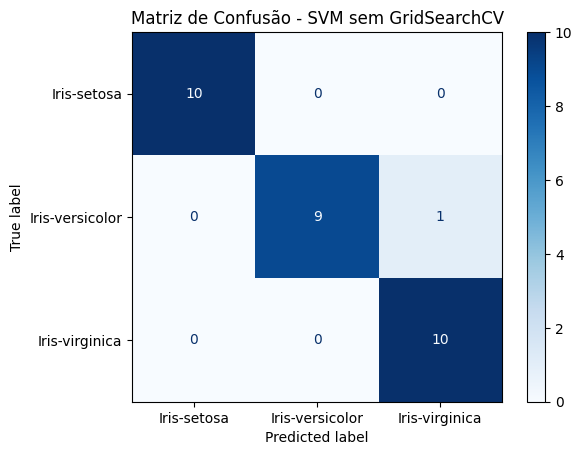

In [2]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("--- SVM - Sem GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_svm, target_names=nomes_classes))

resultados.append([
    'SVM', 'Sem GridSearchCV',
    accuracy_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm, average='macro')
])

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - SVM sem GridSearchCV')
plt.show()


## 2.2 - Com GridSearchCV

Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
--- SVM - Com GridSearchCV ---
Acurácia: 0.9667

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



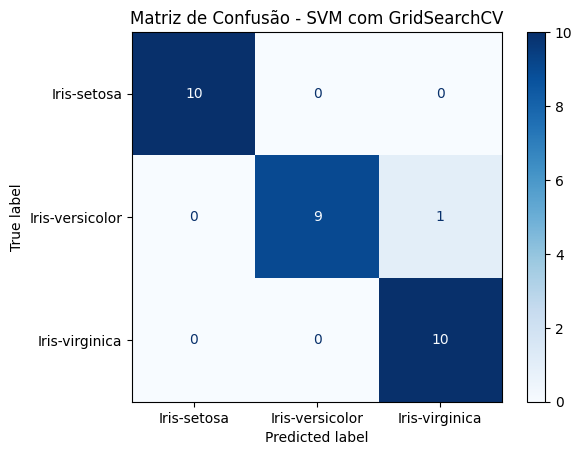

In [3]:
param_grid_svm = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

grid_svm = GridSearchCV(
    SVC(), param_grid_svm, cv=5, scoring='accuracy'
)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm_grid = best_svm.predict(X_test)

print("Melhores parâmetros:", grid_svm.best_params_)

print("--- SVM - Com GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm_grid):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_svm_grid, target_names=nomes_classes))

resultados.append([
    'SVM', 'Com GridSearchCV',
    accuracy_score(y_test, y_pred_svm_grid),
    recall_score(y_test, y_pred_svm_grid, average='macro')
])

cm = confusion_matrix(y_test, y_pred_svm_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - SVM com GridSearchCV')
plt.show()


# 3 - Árvore de Decisão sem e com GridSearchCV

## 3.1 - Sem GridSearchCV

--- Árvore de Decisão - Sem GridSearchCV ---
Acurácia: 0.9333

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



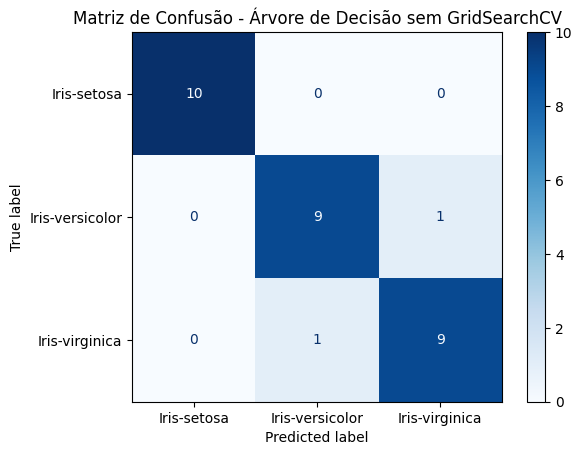

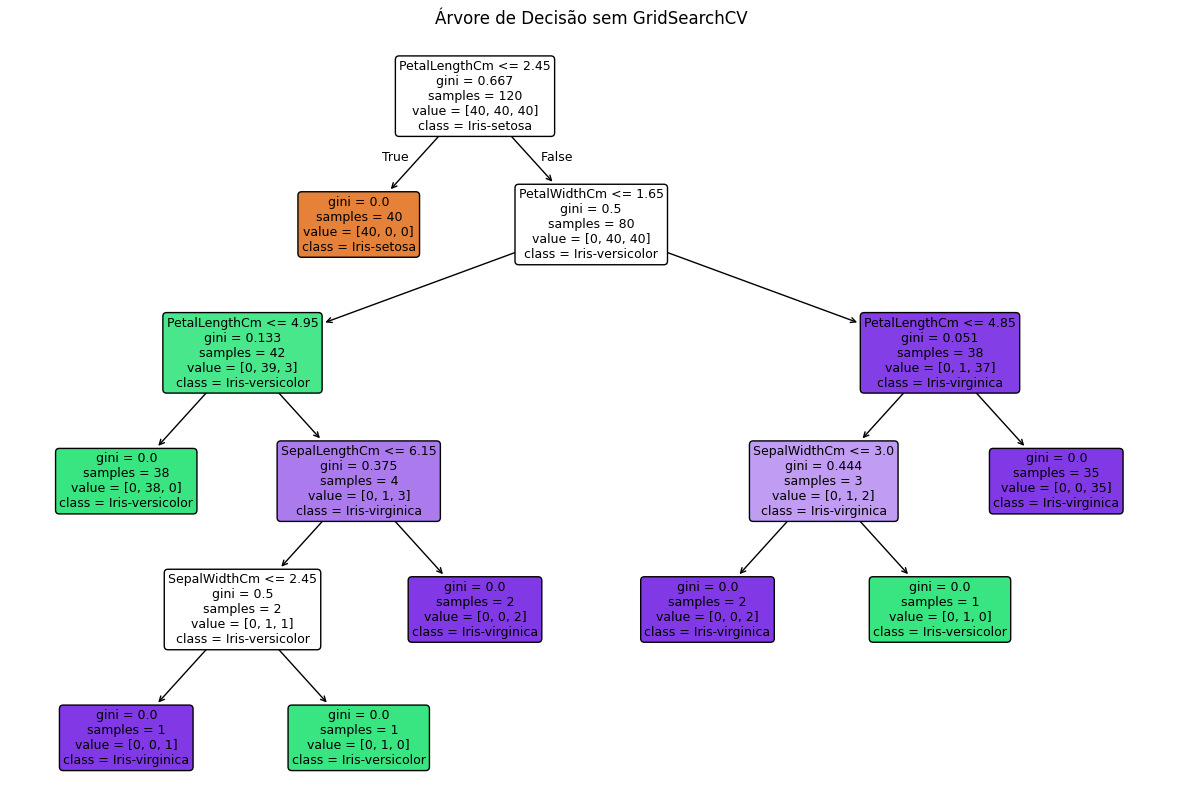

In [4]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)

print("--- Árvore de Decisão - Sem GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_dtc):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_dtc, target_names=nomes_classes))

resultados.append([
    'Árvore de Decisão', 'Sem GridSearchCV',
    accuracy_score(y_test, y_pred_dtc),
    recall_score(y_test, y_pred_dtc, average='macro')
])

cm = confusion_matrix(y_test, y_pred_dtc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão sem GridSearchCV')
plt.show()

plt.figure(figsize=(15, 10))
plot_tree(dtc, feature_names=X.columns, class_names=nomes_classes, filled=True, rounded=True, fontsize=9)
plt.title('Árvore de Decisão sem GridSearchCV')
plt.show()


## 3.2 - Com GridSearchCV

Melhores parâmetros: {'criterion': 'gini', 'max_depth': 5}
--- Árvore de Decisão - Com GridSearchCV ---
Acurácia: 0.9333

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



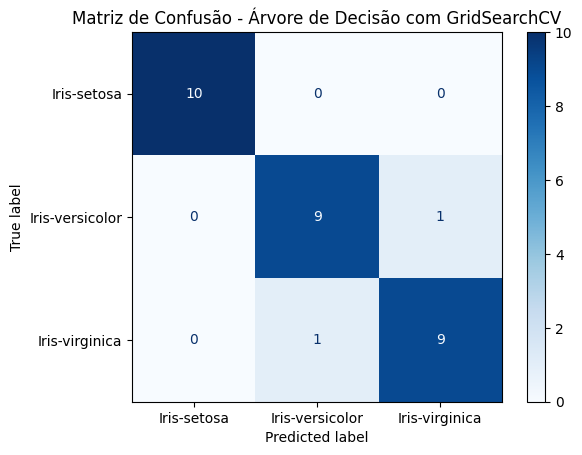

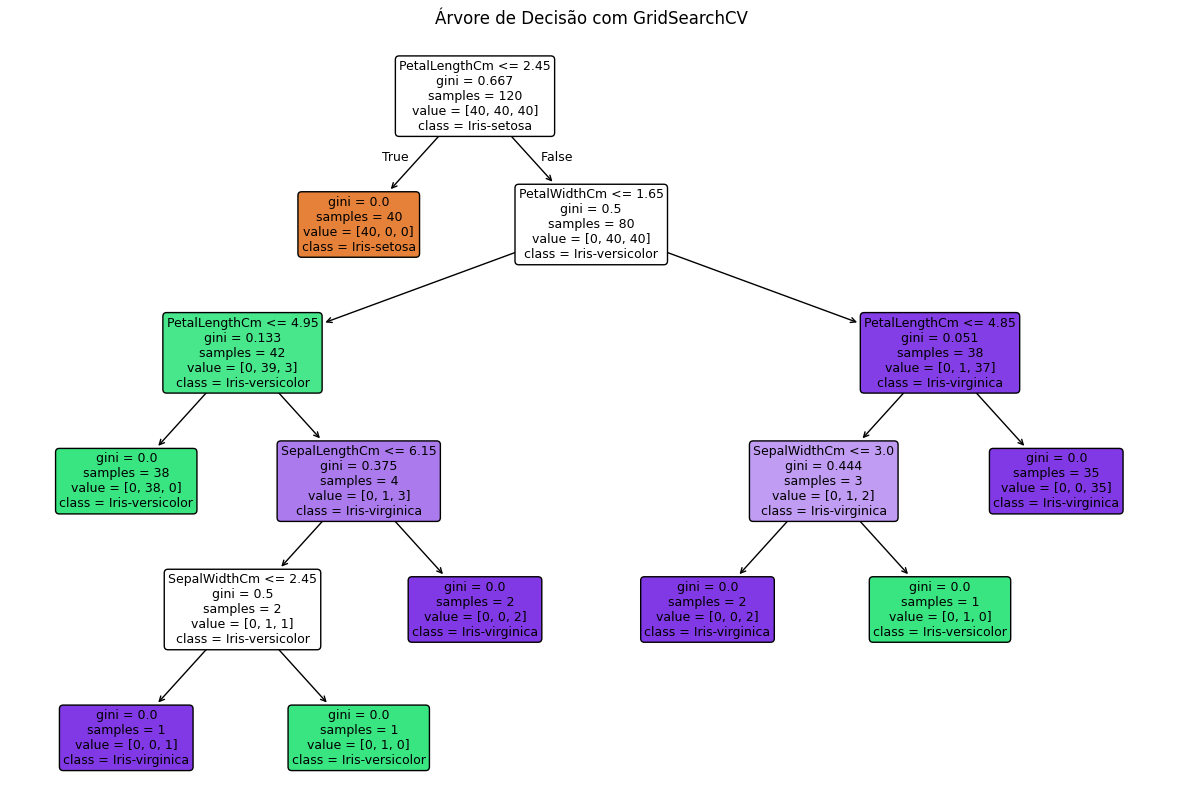

In [5]:
param_grid_dt = {'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 5, None]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy'
)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt_grid = best_dt.predict(X_test)

print("Melhores parâmetros:", grid_dt.best_params_)

print("--- Árvore de Decisão - Com GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_dt_grid):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_dt_grid, target_names=nomes_classes))

resultados.append([
    'Árvore de Decisão', 'Com GridSearchCV',
    accuracy_score(y_test, y_pred_dt_grid),
    recall_score(y_test, y_pred_dt_grid, average='macro')
])

cm = confusion_matrix(y_test, y_pred_dt_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão com GridSearchCV')
plt.show()

plt.figure(figsize=(15, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=nomes_classes, filled=True, rounded=True, fontsize=9)
plt.title('Árvore de Decisão com GridSearchCV')
plt.show()


# 4 - Floresta Aleatória sem e com GridSearchCV

## 4.1 - Sem GridSearchCV

--- Floresta Aleatória - Sem GridSearchCV ---
Acurácia: 0.9000

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



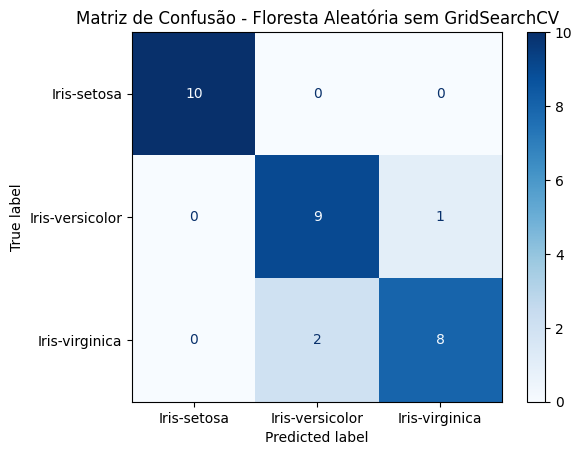

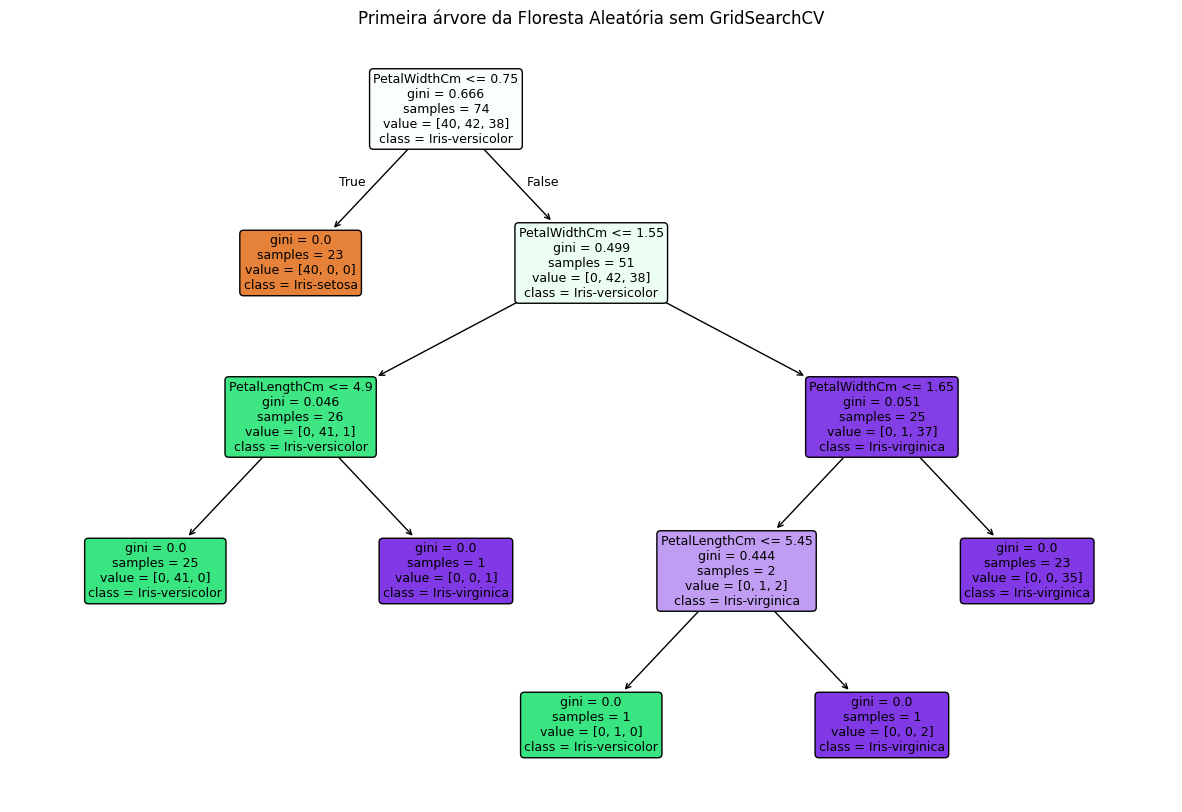

In [6]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)

print("--- Floresta Aleatória - Sem GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rfc):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rfc, target_names=nomes_classes))

resultados.append([
    'Floresta Aleatória', 'Sem GridSearchCV',
    accuracy_score(y_test, y_pred_rfc),
    recall_score(y_test, y_pred_rfc, average='macro')
])

cm = confusion_matrix(y_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Floresta Aleatória sem GridSearchCV')
plt.show()

plt.figure(figsize=(15, 10))
plot_tree(rfc.estimators_[0], feature_names=X.columns, class_names=nomes_classes, filled=True, rounded=True, fontsize=9)
plt.title('Primeira árvore da Floresta Aleatória sem GridSearchCV')
plt.show()


## 4.2 - Com GridSearchCV

Melhores parâmetros: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 50}
--- Floresta Aleatória - Com GridSearchCV ---
Acurácia: 0.9667

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



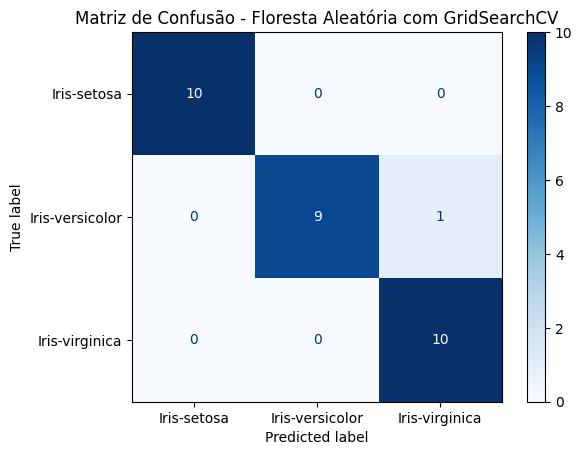

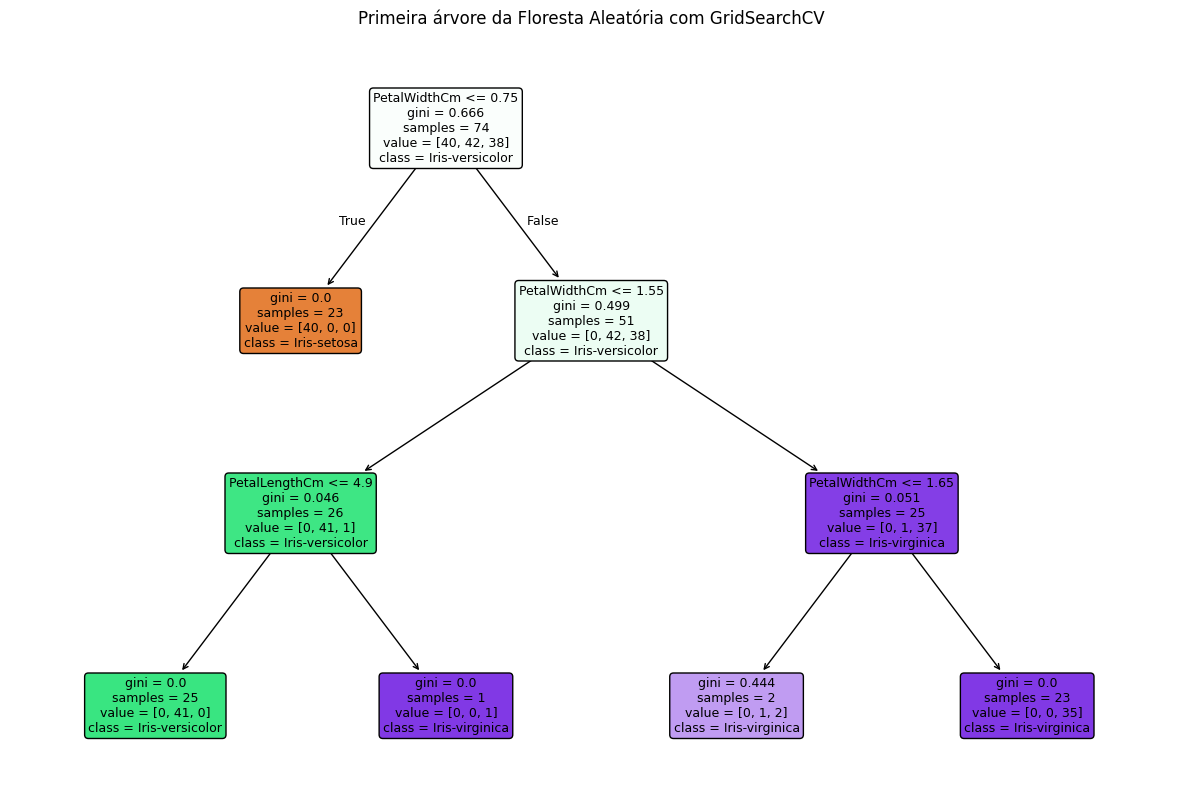

In [7]:
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, None], 'max_features': ['sqrt', 'log2']}

grid_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42), param_grid_rf, cv=5, scoring='accuracy'
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf_grid = best_rf.predict(X_test)

print("Melhores parâmetros:", grid_rf.best_params_)

print("--- Floresta Aleatória - Com GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_grid):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf_grid, target_names=nomes_classes))

resultados.append([
    'Floresta Aleatória', 'Com GridSearchCV',
    accuracy_score(y_test, y_pred_rf_grid),
    recall_score(y_test, y_pred_rf_grid, average='macro')
])

cm = confusion_matrix(y_test, y_pred_rf_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Floresta Aleatória com GridSearchCV')
plt.show()

plt.figure(figsize=(15, 10))
plot_tree(best_rf.estimators_[0], feature_names=X.columns, class_names=nomes_classes, filled=True, rounded=True, fontsize=9)
plt.title('Primeira árvore da Floresta Aleatória com GridSearchCV')
plt.show()


# 5 - XGBoost sem e com GridSearchCV

## 5.1 - Sem GridSearchCV

--- XGBoost - Sem GridSearchCV ---
Acurácia: 0.9333

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



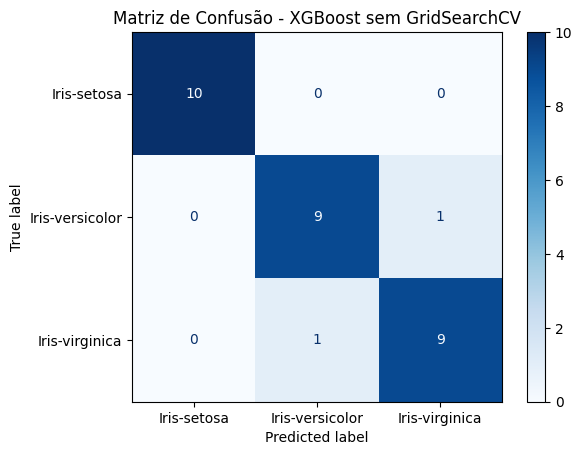

In [8]:
xgbc = xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42, n_jobs=1)
xgbc.fit(X_train, y_train)
y_pred_xgbc = xgbc.predict(X_test)

print("--- XGBoost - Sem GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgbc):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgbc, target_names=nomes_classes))

resultados.append([
    'XGBoost', 'Sem GridSearchCV',
    accuracy_score(y_test, y_pred_xgbc),
    recall_score(y_test, y_pred_xgbc, average='macro')
])

cm = confusion_matrix(y_test, y_pred_xgbc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - XGBoost sem GridSearchCV')
plt.show()


## 5.2 - Com GridSearchCV

Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
--- XGBoost - Com GridSearchCV ---
Acurácia: 0.9333

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



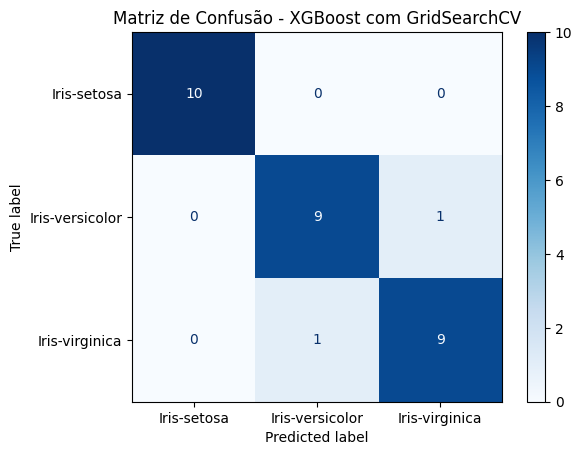

In [9]:
param_grid_xgb = {'n_estimators': [50, 100], 'max_depth': [2, 3], 'learning_rate': [0.1, 0.2]}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42, n_jobs=1), param_grid_xgb, cv=5, scoring='accuracy'
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_grid = best_xgb.predict(X_test)

print("Melhores parâmetros:", grid_xgb.best_params_)

print("--- XGBoost - Com GridSearchCV ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb_grid):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_xgb_grid, target_names=nomes_classes))

resultados.append([
    'XGBoost', 'Com GridSearchCV',
    accuracy_score(y_test, y_pred_xgb_grid),
    recall_score(y_test, y_pred_xgb_grid, average='macro')
])

cm = confusion_matrix(y_test, y_pred_xgb_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - XGBoost com GridSearchCV')
plt.show()


# 6 - Comparação dos resultados

A sensibilidade foi calculada pela média do recall das três espécies. Os modelos foram avaliados com o mesmo conjunto de teste.

In [10]:
comparacao = pd.DataFrame(
    resultados, columns=['Modelo', 'Configuração', 'Acurácia', 'Sensibilidade']
)
print(comparacao.round(4).to_string(index=False))

            Modelo     Configuração  Acurácia  Sensibilidade
               SVM Sem GridSearchCV    0.9667         0.9667
               SVM Com GridSearchCV    0.9667         0.9667
 Árvore de Decisão Sem GridSearchCV    0.9333         0.9333
 Árvore de Decisão Com GridSearchCV    0.9333         0.9333
Floresta Aleatória Sem GridSearchCV    0.9000         0.9000
Floresta Aleatória Com GridSearchCV    0.9667         0.9667
           XGBoost Sem GridSearchCV    0.9333         0.9333
           XGBoost Com GridSearchCV    0.9333         0.9333


## 6.1 - Análise

O SVM, com e sem GridSearchCV, e a Floresta Aleatória com GridSearchCV tiveram os melhores resultados: 96,67% de acurácia e sensibilidade. A Floresta Aleatória passou de 90% para 96,67% com o ajuste dos parâmetros. Nos outros modelos, o GridSearchCV não mudou a acurácia nem a sensibilidade no conjunto de teste.